In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import torch

import sys
sys.path.append('../')
from src.models.staged import STAGED
from src.utils.graph_constructor import GraphConstructor
from src.utils.simulated_data_processing import retrieve_simulated_data,retrieve_real_data

from src.utils.visualization import visualize_attention_graph, visualize_graph

/gpfs/gibbs/project/gerstein/kx44/conda_envs/staged/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /gpfs/gibbs/project/gerstein/kx44/conda_envs/staged/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/gpfs/gibbs/project/gerstein/kx44/conda_envs/staged/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /gpfs/gibbs/project/gerstein/kx44/conda_envs/staged/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/gpfs/gibbs/project/gerstein/kx44/conda_envs/staged/lib/python3.10/site-packages/torch_geometric/typing.

In [2]:
!pwd

/vast/palmer/pi/krishnaswamy_smita/kx44/projects/STAGED/notebooks


In [3]:
data = retrieve_simulated_data(data_dir='/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/STAGED-Simulator/src/staged_simulator/tests/outputs',sim_file='50_simulation_results.pkl')

Valid genes in simulation: ['gene_0', 'gene_1', 'gene_2']
Removing invalid L-R pair: (gene_0, gene_3)
Removing invalid R-G pair: (gene_3, gene_2)
Removing invalid R-G pair: (gene_1, gene_5)
Removing invalid R-G pair: (gene_1, gene_4)
Removing invalid R-G pair: (gene_3, gene_4)


In [ ]:
# from src.utils.data_factory import create_oscillatory_dynamics_data

# data = create_oscillatory_dynamics_data()
# for key, value in data.items():
#     if isinstance(value, (torch.Tensor, np.ndarray)):
#         print(f"{key}: {value.shape}")
#     elif isinstance(value, (list, dict)):
#         print(f"{key}: length {len(value)}")
#     else:
#         print(f"{key}: {value}")
# data = retrieve_real_data(data_dir='../data/real')

In [4]:
for key, value in data.items():
    if isinstance(value, (torch.Tensor, np.ndarray)):
        print(f"{key}: {value.shape}")
    elif isinstance(value, (list, dict)):
        print(f"{key}: length {len(value)}")
    else:
        print(f"{key}: {value}")

gene_expression: torch.Size([50, 10, 3])
cell_positions: torch.Size([50, 10, 2])
genes: length 3
cell_type_assignments: torch.Size([10])
prior_grns: length 1
receptor_gene_pairs: length 0
ligand_receptor_pairs: length 1
n_time_points: 50
n_cells: 10
n_genes: 3


In [ ]:
# import os
# import pickle

# # Load config for future model use
# config_path = os.path.join('../results/checkpoints/checkpoints_20250714_143825', "config.pkl")
# with open(config_path, "rb") as handle:
#     config = pickle.load(handle)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = STAGED(
#     num_genes=len(data['genes']),
#     hidden_dim=config['model_config'].hidden_dim,
#     num_gat_layers=config['model_config'].num_gat_layers,
#     num_mlp_layers=config['model_config'].num_mlp_layers,
#     dropout=config['model_config'].dropout,
#     delta_gl=config['model_config'].delta_gl,
#     delta_lr=config['model_config'].delta_lr,
#     delta_rg=config['model_config'].delta_rg,
#     delta_gg=config['model_config'].delta_gg,
#     add_self_loops=config['model_config'].add_self_loops,
# ).to(device)
# import os
# import pickle

# # Load results object from output directory
# model_path = os.path.join('../results/real/ode/euler', "best_model.pt")
# model.load_state_dict(torch.load(model_path))
# model

UnpicklingError: invalid load key, '{'.

In [6]:
import os
import json
import torch

config_path = os.path.join('../results/checkpoints/checkpoints_20250714_143825', "config.json")
try:
    with open(config_path, "r") as handle:
        config = json.load(handle)
    print("Loaded config from JSON file")
except FileNotFoundError:
    # If config.json doesn't exist, try to read the .pkl file as JSON
    pkl_path = os.path.join('../results/checkpoints/checkpoints_20250714_143825', "config.pkl")
    with open(pkl_path, "r") as handle:  # Read as text, not binary
        config = json.load(handle)
    print("Loaded config from .pkl file (which was actually JSON)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create model with correct config structure
model_config = config['model']
model = STAGED(
    num_genes=len(data['genes']),
    hidden_dim=model_config['hidden_dim'],
    num_gat_layers=model_config['num_gat_layers'],
    num_mlp_layers=model_config['num_mlp_layers'],
    dropout=model_config['dropout'],
    delta_gl=model_config['delta_gl'],
    delta_lr=model_config['delta_lr'],
    delta_rg=model_config['delta_rg'],
    delta_gg=model_config['delta_gg'],
    add_self_loops=model_config['add_self_loops'],
).to(device)

# Load checkpoint
model_path = os.path.join('../results/checkpoints/checkpoints_20250714_143825', "best_model.pt")
checkpoint = torch.load(model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully!")

Loaded config from JSON file
Model loaded successfully!


In [7]:
data['genes']

['gene_0', 'gene_1', 'gene_2']

In [8]:
data['ligand_receptor_pairs']

[('gene_2', 'gene_1')]

In [9]:
data['cell_type_assignments']

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [10]:
graph_constructor = GraphConstructor(
    genes=data['genes'],
    ligand_receptor_pairs=data['ligand_receptor_pairs'],
    receptor_gene_pairs=data['receptor_gene_pairs'],
    cell_type_assignments=data['cell_type_assignments'],
    prior_grns=data['prior_grns']
)

# Define time lags as specified by the user
delta_gl = 1  # Time lag for gene -> ligand
delta_lr = 2  # Time lag for ligand -> receptor
delta_rg = 1  # Time lag for receptor -> gene
delta_gg = 0  # Time lag for gene -> gene

time_point = 8
cell_idx = 0

# Ensure time_point is large enough to handle the lags
max_lag = max(delta_gl, delta_lr, delta_rg, delta_gg)
if time_point < max_lag:
    time_point = max_lag
    print(f"Adjusted time_point to {time_point} to handle time lags")


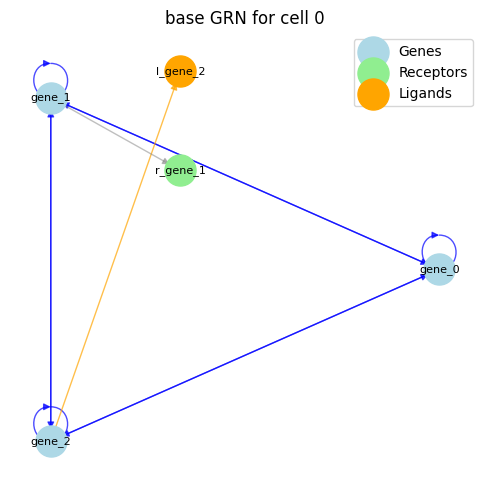

In [11]:
base_graph = graph_constructor.construct_base_graph(cell_idx)
visualize_graph(base_graph, f"base GRN for cell {cell_idx}", save_plot=False, show_plot=True, figsize=(5, 5))

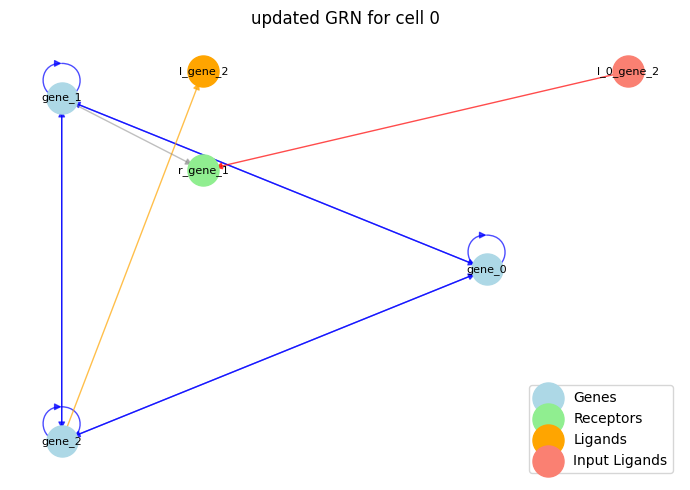

In [12]:
distance_threshold = 1
updated_graph = graph_constructor.update_graph_with_neighbors(
    base_graph, cell_idx, data['cell_positions'], time_point,
    distance_threshold=distance_threshold
)
pos = visualize_graph(updated_graph, f"updated GRN for cell {cell_idx}", save_plot=False, show_plot=True, figsize=(7, 5), return_pos=True)


In [13]:
import matplotlib.pyplot as plt
def visualize_attention_graph(pyg_graph, edge_index, attention_weights, pos, figsize=(12, 10), show_labels=True):
    """
    Visualize a graph with attention weights and node types.
    
    Args:
        pyg_graph: PyTorch Geometric graph object containing node names and types
        edge_index: Tensor containing edge indices
        attention_weights: Tensor containing attention weights
            from `node_embeddings, (edge_index, attention_weights) = model(pyg_graph)`
        pos: Dictionary mapping node names to positions
        figsize: Tuple specifying figure size
        show_labels: Whether to show node labels (default: True)
        
    Returns:
        None. Displays the graph visualization.
    """
    # Create a NetworkX graph from edge_index with node names
    G = nx.DiGraph()
    node_names = pyg_graph.node_names
    edge_list = [(node_names[src], node_names[dst]) for src, dst in edge_index.t().tolist()]
    G.add_edges_from(edge_list)

    # Create mapping from node names to their types
    node_name_to_type = {name: type_ for name, type_ in zip(pyg_graph.node_names, pyg_graph.node_types)}

    # Compute average attention weights across heads for visualization
    avg_attention = attention_weights.mean(dim=1).detach().numpy()

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create color map for node types
    node_type_colors = {
        'gene': 'lightblue',
        'receptor': 'lightgreen', 
        'ligand': 'orange',
        'input_ligand': 'salmon'
    }

    # Get node colors based on type, using the NetworkX graph node order
    node_colors = [node_type_colors[node_name_to_type[node]] for node in G.nodes()]

    # Draw graph with attention weights as edge colors and labels
    nx.draw(G, pos, ax=ax, with_labels=show_labels, node_color=node_colors,
            edge_color=avg_attention, edge_cmap=plt.cm.Blues, width=2,
            labels={node: node for node in G.nodes()} if show_labels else {})

    # Add edge labels showing attention weights
    # Create edge labels dictionary including self-loops
    edge_labels = {}
    for (src, dst), att in zip(edge_index.t().tolist(), avg_attention):
        src_name = node_names[src]
        dst_name = node_names[dst]
        edge_labels[(src_name, dst_name)] = f'{att:.2f}'
        # For self-loops, adjust position slightly to make label visible
        if src == dst:
            pos_adj = {node: (x + 0.1, y + 0.1) for node, (x, y) in pos.items()}
            nx.draw_networkx_edge_labels(G, pos_adj, edge_labels={(src_name, dst_name): edge_labels[(src_name, dst_name)]}, ax=ax)
    
    # Draw labels for non-self-loop edges
    non_self_loops = {(s, d): l for (s, d), l in edge_labels.items() if s != d}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=non_self_loops, ax=ax)

    # Add colorbar for attention weights
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues,
                              norm=plt.Normalize(vmin=avg_attention.min(),
                                               vmax=avg_attention.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Average Attention Weight')

    # Add legend for node types
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=color, label=node_type, markersize=10)
                      for node_type, color in node_type_colors.items()]
    ax.legend(handles=legend_elements, loc='lower right', title='Node Types')

    ax2 = ax.twinx()
    ax2.set_yticks([])

    ax.set_title('Graph with Attention Weights and Values')

    plt.tight_layout()
    plt.show()

In [14]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene, 
                           figsize=(12, 10), show_labels=True, highlight_mode='both'):
    """
    Visualize a graph with attention weights focused on a specific gene.
    
    Args:
        pyg_graph: PyTorch Geometric graph object containing node names and types
        edge_index: Tensor containing edge indices
        attention_weights: Tensor containing attention weights
            from `node_embeddings, (edge_index, attention_weights) = model(pyg_graph)`
        pos: Dictionary mapping node names to positions
        target_gene: Name of the gene to focus on
        figsize: Tuple specifying figure size
        show_labels: Whether to show node labels (default: True)
        highlight_mode: 'incoming', 'outgoing', or 'both' (default: 'both')
        
    Returns:
        None. Displays the graph visualization.
    """
    # Create a NetworkX graph from edge_index with node names
    G = nx.DiGraph()
    node_names = pyg_graph.node_names
    edge_list = [(node_names[src], node_names[dst]) for src, dst in edge_index.t().tolist()]
    G.add_edges_from(edge_list)

    # Check if target gene exists
    if target_gene not in node_names:
        print(f"Warning: Gene '{target_gene}' not found in the graph.")
        print(f"Available genes: {[name for name, type_ in zip(node_names, pyg_graph.node_types) if type_ == 'gene']}")
        return

    # Create mapping from node names to their types
    node_name_to_type = {name: type_ for name, type_ in zip(pyg_graph.node_names, pyg_graph.node_types)}

    # Compute average attention weights across heads for visualization
    avg_attention = attention_weights.mean(dim=1).detach().numpy()

    # Find edges related to target gene
    target_edges = []
    target_attention_weights = []
    other_edges = []
    other_attention_weights = []
    
    for i, (src, dst) in enumerate(edge_index.t().tolist()):
        src_name = node_names[src]
        dst_name = node_names[dst]
        
        is_target_edge = False
        if highlight_mode == 'incoming' and dst_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'outgoing' and src_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'both' and (src_name == target_gene or dst_name == target_gene):
            is_target_edge = True
            
        if is_target_edge:
            target_edges.append((src_name, dst_name))
            target_attention_weights.append(avg_attention[i])
        else:
            other_edges.append((src_name, dst_name))
            other_attention_weights.append(avg_attention[i])

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create color map for node types
    node_type_colors = {
        'gene': 'lightblue',
        'receptor': 'lightgreen', 
        'ligand': 'orange',
        'input_ligand': 'salmon'
    }

    # Get node colors, highlighting target gene
    node_colors = []
    for node in G.nodes():
        if node == target_gene:
            node_colors.append('red')  # Highlight target gene in red
        else:
            node_colors.append(node_type_colors[node_name_to_type[node]])

    # Draw all nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=300)
    
    # Draw non-target edges with low opacity
    if other_edges:
        other_G = nx.DiGraph()
        other_G.add_edges_from(other_edges)
        nx.draw_networkx_edges(other_G, pos, ax=ax, edge_color='lightgray', 
                              width=0.5, alpha=0.3, arrows=True, arrowsize=10)
    
    # Draw target edges with attention-based coloring
    if target_edges:
        target_G = nx.DiGraph()
        target_G.add_edges_from(target_edges)
        
        # Normalize attention weights for better visualization
        if len(target_attention_weights) > 1:
            norm_weights = np.array(target_attention_weights)
            norm_weights = (norm_weights - norm_weights.min()) / (norm_weights.max() - norm_weights.min() + 1e-8)
        else:
            norm_weights = target_attention_weights
            
        nx.draw_networkx_edges(target_G, pos, ax=ax, edge_color=target_attention_weights,
                              edge_cmap=plt.cm.Reds, width=3, arrows=True, arrowsize=15)

    # Add node labels if requested
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax)

    # Add edge labels for target edges only
    target_edge_labels = {}
    for edge, att in zip(target_edges, target_attention_weights):
        target_edge_labels[edge] = f'{att:.3f}'
    
    if target_edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=target_edge_labels, 
                                    ax=ax, font_size=8, bbox=dict(boxstyle='round,pad=0.2', 
                                    facecolor='white', alpha=0.8))

    # Add colorbar for target attention weights
    if target_attention_weights:
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                  norm=plt.Normalize(vmin=min(target_attention_weights),
                                                   vmax=max(target_attention_weights)))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label=f'Attention Weight for {target_gene}')

    # Add legend for node types (including highlighted target)
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=color, label=node_type, markersize=10)
                      for node_type, color in node_type_colors.items()]
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                    markerfacecolor='red', label=f'Target: {target_gene}', markersize=10))
    ax.legend(handles=legend_elements, loc='lower right', title='Node Types')

    # Set title based on highlight mode
    mode_text = {
        'incoming': f'Incoming connections to {target_gene}',
        'outgoing': f'Outgoing connections from {target_gene}',
        'both': f'All connections for {target_gene}'
    }
    
    ax.set_title(f'Gene Attention Visualization: {mode_text[highlight_mode]}')
    
    # Print summary statistics
    if target_attention_weights:
        print(f"\nAttention Statistics for {target_gene}:")
        print(f"Number of highlighted edges: {len(target_attention_weights)}")
        print(f"Average attention weight: {np.mean(target_attention_weights):.4f}")
        print(f"Max attention weight: {np.max(target_attention_weights):.4f}")
        print(f"Min attention weight: {np.min(target_attention_weights):.4f}")
        
        # Show top connections
        if len(target_edges) > 0:
            sorted_connections = sorted(zip(target_edges, target_attention_weights), 
                                      key=lambda x: x[1], reverse=True)
            print(f"\nTop connections (by attention weight):")
            for i, ((src, dst), weight) in enumerate(sorted_connections[:5]):
                direction = f"{src} → {dst}" if src != target_gene else f"{dst} → {src}"
                print(f"  {i+1}. {direction}: {weight:.4f}")

    plt.tight_layout()
    plt.show()


In [15]:
pyg_graph = graph_constructor.assign_node_features(
    updated_graph, cell_idx, time_point, data['gene_expression'],
    delta_gl, delta_lr, delta_rg, delta_gg
)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model device: {next(model.parameters()).device}")
print(f"Current data device: {pyg_graph.x.device if hasattr(pyg_graph, 'x') else 'Unknown'}")

# Move the PyG graph to the correct device
pyg_graph = pyg_graph.to(device)
print(f"Data moved to device: {pyg_graph.x.device}")

# Now run inference
with torch.no_grad():  # Disable gradient computation for inference
    node_embeddings, (edge_index, attention_weights) = model(pyg_graph)
    
print("Model inference completed successfully!")
print(f"Node embeddings shape: {node_embeddings.shape}")
print(f"Attention weights shape: {attention_weights.shape}")


Model device: cuda:0
Current data device: cpu
Data moved to device: cuda:0
Model inference completed successfully!
Node embeddings shape: torch.Size([6, 64])
Attention weights shape: torch.Size([15, 1])


In [16]:
node_embeddings, (edge_index, attention_weights) = model(pyg_graph)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat2 in method wrapper_CUDA_mm)

In [18]:
visualize_attention_graph(pyg_graph, edge_index, attention_weights, pos, figsize=(12, 10))

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

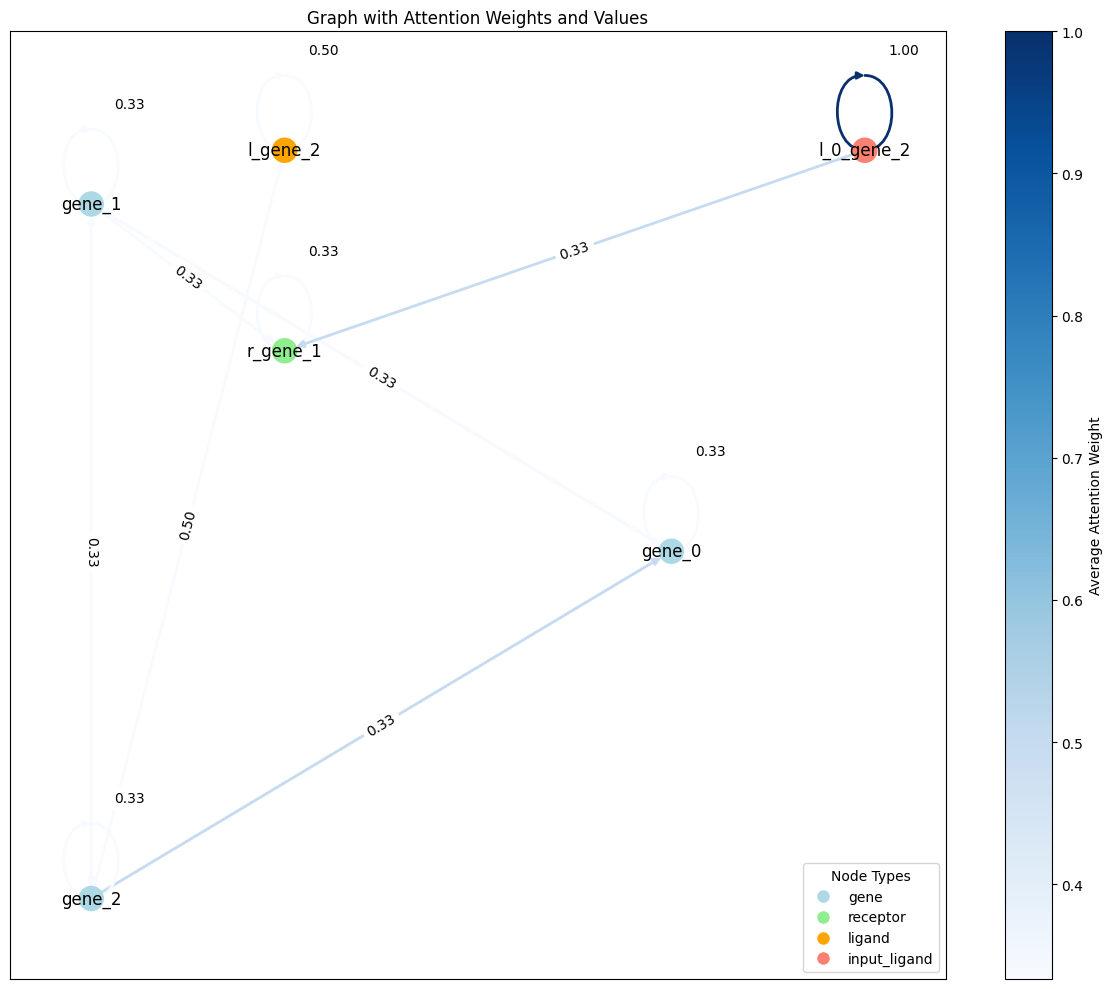

In [19]:
attention_weights_cpu = attention_weights.detach().cpu()
edge_index_cpu = edge_index.detach().cpu()

# Then call your visualization function
visualize_attention_graph(pyg_graph, edge_index_cpu, attention_weights_cpu, pos, figsize=(12, 10))

In [20]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_single_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene, 
                           figsize=(12, 10), show_labels=True, highlight_mode='both'):
    """
    Visualize a graph with attention weights focused on a specific gene.
    
    Args:
        pyg_graph: PyTorch Geometric graph object containing node names and types
        edge_index: Tensor containing edge indices
        attention_weights: Tensor containing attention weights
            from `node_embeddings, (edge_index, attention_weights) = model(pyg_graph)`
        pos: Dictionary mapping node names to positions
        target_gene: Name of the gene to focus on
        figsize: Tuple specifying figure size
        show_labels: Whether to show node labels (default: True)
        highlight_mode: 'incoming', 'outgoing', or 'both' (default: 'both')
        
    Returns:
        None. Displays the graph visualization.
    """
    # Create a NetworkX graph from edge_index with node names
    G = nx.DiGraph()
    node_names = pyg_graph.node_names
    edge_list = [(node_names[src], node_names[dst]) for src, dst in edge_index.t().tolist()]
    G.add_edges_from(edge_list)

    # Check if target gene exists
    if target_gene not in node_names:
        print(f"Warning: Gene '{target_gene}' not found in the graph.")
        print(f"Available genes: {[name for name, type_ in zip(node_names, pyg_graph.node_types) if type_ == 'gene']}")
        return

    # Create mapping from node names to their types
    node_name_to_type = {name: type_ for name, type_ in zip(pyg_graph.node_names, pyg_graph.node_types)}

    # Compute average attention weights across heads for visualization
    avg_attention = attention_weights.mean(dim=1).detach().numpy()

    # Find edges related to target gene
    target_edges = []
    target_attention_weights = []
    other_edges = []
    other_attention_weights = []
    
    for i, (src, dst) in enumerate(edge_index.t().tolist()):
        src_name = node_names[src]
        dst_name = node_names[dst]
        
        is_target_edge = False
        if highlight_mode == 'incoming' and dst_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'outgoing' and src_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'both' and (src_name == target_gene or dst_name == target_gene):
            is_target_edge = True
            
        if is_target_edge:
            target_edges.append((src_name, dst_name))
            target_attention_weights.append(avg_attention[i])
        else:
            other_edges.append((src_name, dst_name))
            other_attention_weights.append(avg_attention[i])

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create color map for node types
    node_type_colors = {
        'gene': 'lightblue',
        'receptor': 'lightgreen', 
        'ligand': 'orange',
        'input_ligand': 'salmon'
    }

    # Get node colors, highlighting target gene
    node_colors = []
    for node in G.nodes():
        if node == target_gene:
            node_colors.append('red')  # Highlight target gene in red
        else:
            node_colors.append(node_type_colors[node_name_to_type[node]])

    # Draw all nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=300)
    
    # Draw non-target edges with low opacity
    if other_edges:
        other_G = nx.DiGraph()
        other_G.add_edges_from(other_edges)
        nx.draw_networkx_edges(other_G, pos, ax=ax, edge_color='lightgray', 
                              width=0.5, alpha=0.3, arrows=True, arrowsize=10)
    
    # Draw target edges with attention-based coloring
    if target_edges:
        target_G = nx.DiGraph()
        target_G.add_edges_from(target_edges)
        
        # Normalize attention weights for better visualization
        if len(target_attention_weights) > 1:
            norm_weights = np.array(target_attention_weights)
            norm_weights = (norm_weights - norm_weights.min()) / (norm_weights.max() - norm_weights.min() + 1e-8)
        else:
            norm_weights = target_attention_weights
            
        nx.draw_networkx_edges(target_G, pos, ax=ax, edge_color=target_attention_weights,
                              edge_cmap=plt.cm.Reds, width=3, arrows=True, arrowsize=15)

    # Add node labels if requested
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax)

    # Add edge labels for target edges only
    target_edge_labels = {}
    for edge, att in zip(target_edges, target_attention_weights):
        target_edge_labels[edge] = f'{att:.3f}'
    
    if target_edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=target_edge_labels, 
                                    ax=ax, font_size=8, bbox=dict(boxstyle='round,pad=0.2', 
                                    facecolor='white', alpha=0.8))

    # Add colorbar for target attention weights
    if target_attention_weights:
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                  norm=plt.Normalize(vmin=min(target_attention_weights),
                                                   vmax=max(target_attention_weights)))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label=f'Attention Weight for {target_gene}')

    # Add legend for node types (including highlighted target)
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=color, label=node_type, markersize=10)
                      for node_type, color in node_type_colors.items()]
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                    markerfacecolor='red', label=f'Target: {target_gene}', markersize=10))
    ax.legend(handles=legend_elements, loc='lower right', title='Node Types')

    # Set title based on highlight mode
    mode_text = {
        'incoming': f'Incoming connections to {target_gene}',
        'outgoing': f'Outgoing connections from {target_gene}',
        'both': f'All connections for {target_gene}'
    }
    
    ax.set_title(f'Gene Attention Visualization: {mode_text[highlight_mode]}')
    
    # Print summary statistics
    if target_attention_weights:
        print(f"\nAttention Statistics for {target_gene}:")
        print(f"Number of highlighted edges: {len(target_attention_weights)}")
        print(f"Average attention weight: {np.mean(target_attention_weights):.4f}")
        print(f"Max attention weight: {np.max(target_attention_weights):.4f}")
        print(f"Min attention weight: {np.min(target_attention_weights):.4f}")
        
        # Show top connections
        if len(target_edges) > 0:
            sorted_connections = sorted(zip(target_edges, target_attention_weights), 
                                      key=lambda x: x[1], reverse=True)
            print(f"\nTop connections (by attention weight):")
            for i, ((src, dst), weight) in enumerate(sorted_connections[:5]):
                direction = f"{src} → {dst}" if src != target_gene else f"{dst} → {src}"
                print(f"  {i+1}. {direction}: {weight:.4f}")

    plt.tight_layout()
    plt.show()


In [21]:
visualize_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene='gene_1', figsize=(12, 10))

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.


Attention Statistics for gene_1:
Number of highlighted edges: 6
Average attention weight: 0.3333
Max attention weight: 0.3333
Min attention weight: 0.3333

Top connections (by attention weight):
  1. gene_0 → gene_1: 0.3333
  2. r_gene_1 → gene_1: 0.3333
  3. gene_2 → gene_1: 0.3333
  4. gene_0 → gene_1: 0.3333
  5. gene_2 → gene_1: 0.3333


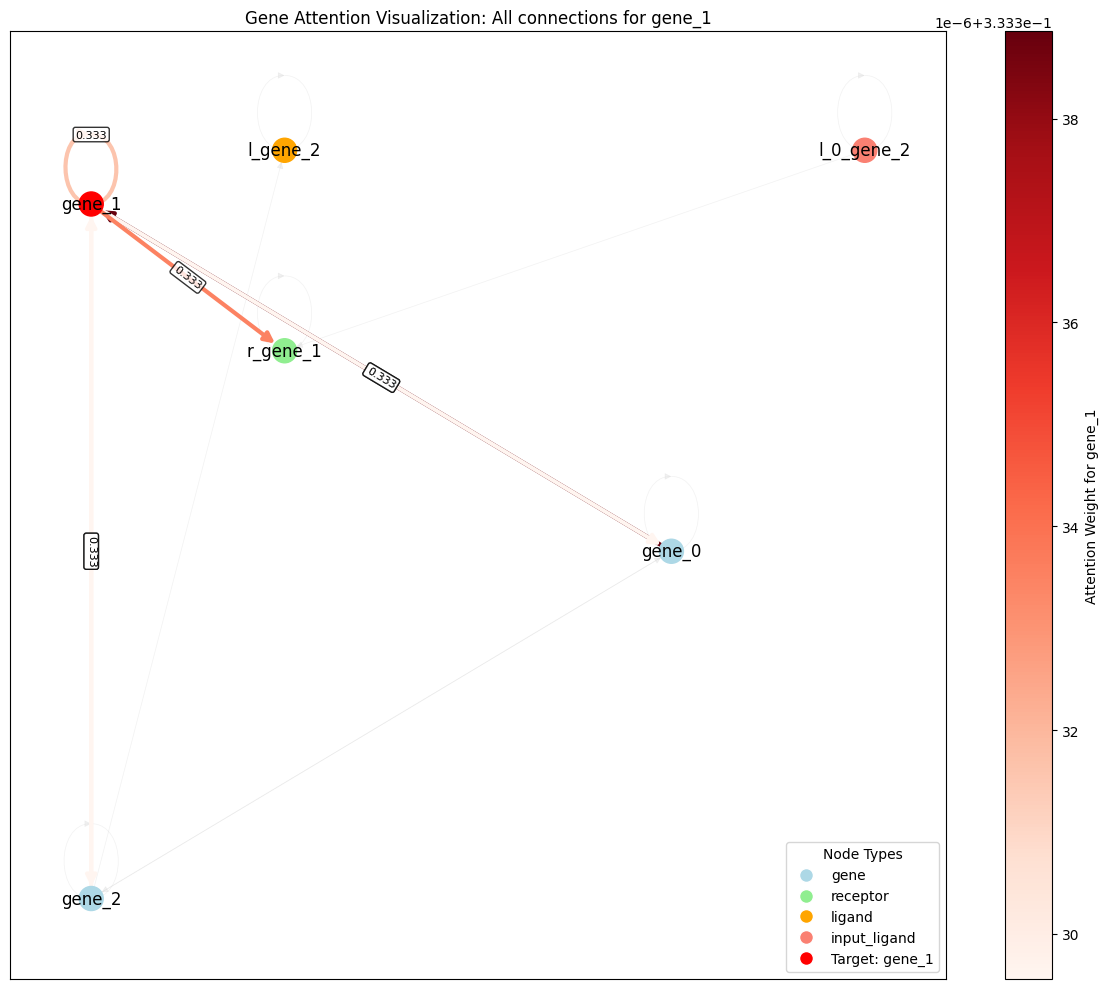

In [22]:
attention_weights_cpu = attention_weights.detach().cpu()
edge_index_cpu = edge_index.detach().cpu()
visualize_gene_attention(pyg_graph, edge_index_cpu, attention_weights_cpu, pos, 
                        target_gene='gene_1', figsize=(12, 10))


In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_single_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene, 
                           figsize=(12, 10), show_labels=True, highlight_mode='both', top_k=10):
    """
    Visualize a graph with attention weights focused on a specific gene and its most attended connections.
    
    Args:
        pyg_graph: PyTorch Geometric graph object containing node names and types
        edge_index: Tensor containing edge indices
        attention_weights: Tensor containing attention weights
            from `node_embeddings, (edge_index, attention_weights) = model(pyg_graph)`
        pos: Dictionary mapping node names to positions
        target_gene: Name of the gene to focus on
        figsize: Tuple specifying figure size
        show_labels: Whether to show node labels (default: True)
        highlight_mode: 'incoming', 'outgoing', or 'both' (default: 'both')
        top_k: Number of top attention connections to display (default: 10)
        
    Returns:
        None. Displays the graph visualization.
    """
    # Create node names mapping
    node_names = pyg_graph.node_names

    # Check if target gene exists
    if target_gene not in node_names:
        print(f"Warning: Gene '{target_gene}' not found in the graph.")
        print(f"Available genes: {[name for name, type_ in zip(node_names, pyg_graph.node_types) if type_ == 'gene']}")
        return

    # Create mapping from node names to their types
    node_name_to_type = {name: type_ for name, type_ in zip(pyg_graph.node_names, pyg_graph.node_types)}

    # Compute average attention weights across heads for visualization
    avg_attention = attention_weights.mean(dim=1).detach().numpy()

    # Find edges related to target gene and their attention weights
    target_connections = []
    
    for i, (src, dst) in enumerate(edge_index.t().tolist()):
        src_name = node_names[src]
        dst_name = node_names[dst]
        
        is_target_edge = False
        if highlight_mode == 'incoming' and dst_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'outgoing' and src_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'both' and (src_name == target_gene or dst_name == target_gene):
            is_target_edge = True
            
        if is_target_edge:
            target_connections.append((src_name, dst_name, avg_attention[i]))

    if not target_connections:
        print(f"No connections found for {target_gene} in {highlight_mode} mode.")
        return

    # Sort by attention weight and take top_k connections
    target_connections.sort(key=lambda x: x[2], reverse=True)
    top_connections = target_connections[:top_k]

    # Extract nodes involved in top connections
    nodes_to_plot = {target_gene}
    edges_to_plot = []
    attention_values = []
    
    for src, dst, att in top_connections:
        nodes_to_plot.add(src)
        nodes_to_plot.add(dst)
        edges_to_plot.append((src, dst))
        attention_values.append(att)

    # Create a focused NetworkX graph with only relevant nodes and edges
    G = nx.DiGraph()
    G.add_nodes_from(nodes_to_plot)
    G.add_edges_from(edges_to_plot)

    # Filter positions to only include nodes we're plotting
    filtered_pos = {node: pos[node] for node in nodes_to_plot if node in pos}
    
    # If some nodes don't have positions, create a layout for the subgraph
    if len(filtered_pos) < len(nodes_to_plot):
        missing_nodes = nodes_to_plot - set(filtered_pos.keys())
        print(f"Warning: Position not found for nodes: {missing_nodes}")
        # Use spring layout for the focused subgraph
        filtered_pos = nx.spring_layout(G, pos=filtered_pos, fixed=list(filtered_pos.keys()))

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create color map for node types
    node_type_colors = {
        'gene': 'lightblue',
        'receptor': 'lightgreen', 
        'ligand': 'orange',
        'input_ligand': 'salmon'
    }

    # Get node colors, highlighting target gene
    node_colors = []
    node_sizes = []
    for node in G.nodes():
        if node == target_gene:
            node_colors.append('red')  # Highlight target gene in red
            node_sizes.append(500)  # Make target gene larger
        else:
            node_colors.append(node_type_colors.get(node_name_to_type[node], 'gray'))
            node_sizes.append(300)

    # Draw nodes
    nx.draw_networkx_nodes(G, filtered_pos, ax=ax, node_color=node_colors, node_size=node_sizes)
    
    # Draw edges with attention-based coloring and width
    if edges_to_plot:
        # Normalize attention weights for better visualization
        if len(attention_values) > 1:
            norm_weights = np.array(attention_values)
            min_att, max_att = norm_weights.min(), norm_weights.max()
            if max_att > min_att:
                norm_weights = (norm_weights - min_att) / (max_att - min_att)
            else:
                norm_weights = np.ones_like(norm_weights)
        else:
            norm_weights = np.array([1.0])
            
        # Scale edge widths based on attention (1-5 range)
        edge_widths = 1 + 4 * norm_weights
        
        nx.draw_networkx_edges(G, filtered_pos, ax=ax, edge_color=attention_values,
                              edge_cmap=plt.cm.Reds, width=edge_widths, arrows=True, 
                              arrowsize=20, connectionstyle="arc3,rad=0.1")

    # Add node labels if requested
    if show_labels:
        # Make target gene label bold
        label_dict = {}
        for node in G.nodes():
            if node == target_gene:
                label_dict[node] = f"**{node}**"
            else:
                label_dict[node] = node
        nx.draw_networkx_labels(G, filtered_pos, labels=label_dict, ax=ax, font_size=10, font_weight='bold')

    # Add edge labels for attention weights
    edge_labels = {}
    for (src, dst), att in zip(edges_to_plot, attention_values):
        edge_labels[(src, dst)] = f'{att:.3f}'
    
    nx.draw_networkx_edge_labels(G, filtered_pos, edge_labels=edge_labels, 
                                ax=ax, font_size=8, bbox=dict(boxstyle='round,pad=0.2', 
                                facecolor='white', alpha=0.8))

    # Add colorbar for attention weights
    if attention_values:
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                  norm=plt.Normalize(vmin=min(attention_values),
                                                   vmax=max(attention_values)))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label=f'Attention Weight')

    # Add legend for node types (including highlighted target)
    legend_elements = []
    present_types = set(node_name_to_type[node] for node in nodes_to_plot if node != target_gene)
    
    for node_type in present_types:
        if node_type in node_type_colors:
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                            markerfacecolor=node_type_colors[node_type], 
                                            label=node_type, markersize=10))
    
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                    markerfacecolor='red', label=f'Target: {target_gene}', markersize=12))
    
    ax.legend(handles=legend_elements, loc='upper right', title='Node Types')

    # Set title based on highlight mode
    mode_text = {
        'incoming': f'Top {len(edges_to_plot)} incoming connections to {target_gene}',
        'outgoing': f'Top {len(edges_to_plot)} outgoing connections from {target_gene}',
        'both': f'Top {len(edges_to_plot)} connections for {target_gene}'
    }
    
    ax.set_title(f'Focused Gene Attention Visualization: {mode_text[highlight_mode]}', 
                 fontsize=14, fontweight='bold')
    
    # Remove axis for cleaner look
    ax.set_axis_off()
    
    # Print summary statistics
    print(f"\nFocused Attention Analysis for {target_gene}:")
    print(f"Showing top {len(edges_to_plot)} of {len(target_connections)} total connections")
    print(f"Nodes in visualization: {len(nodes_to_plot)}")
    print(f"Average attention weight (shown): {np.mean(attention_values):.4f}")
    print(f"Max attention weight (shown): {np.max(attention_values):.4f}")
    print(f"Min attention weight (shown): {np.min(attention_values):.4f}")
    
    # Show the connections with their weights
    print(f"\nTop {len(edges_to_plot)} connections (by attention weight):")
    for i, (src, dst, weight) in enumerate(top_connections):
        if src == target_gene:
            direction = f"{target_gene} → {dst}"
        else:
            direction = f"{src} → {target_gene}"
        print(f"  {i+1}. {direction}: {weight:.4f}")

    plt.tight_layout()
    plt.show()
    
    return G, filtered_pos, attention_values


Focused Attention Analysis for gene_1:
Showing top 6 of 6 total connections
Nodes in visualization: 4
Average attention weight (shown): 0.3333
Max attention weight (shown): 0.3333
Min attention weight (shown): 0.3333

Top 6 connections (by attention weight):
  1. gene_0 → gene_1: 0.3333
  2. gene_1 → r_gene_1: 0.3333
  3. gene_2 → gene_1: 0.3333
  4. gene_1 → gene_0: 0.3333
  5. gene_1 → gene_2: 0.3333
  6. gene_1 → gene_1: 0.3333


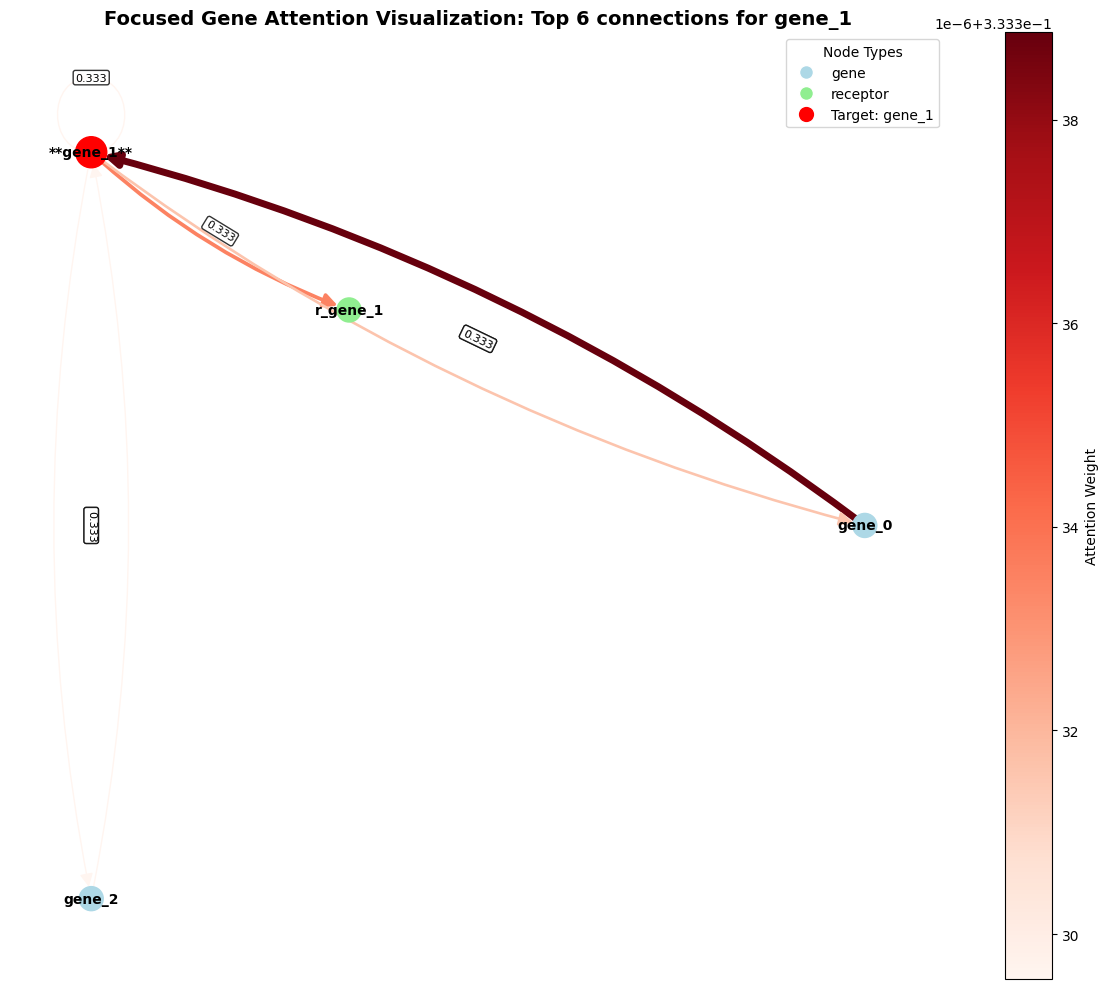

(<networkx.classes.digraph.DiGraph at 0x14bf29df2470>,
 {'gene_0': (np.float64(1.0), np.float64(-0.49999998013178487)),
  'gene_1': (np.float64(-0.5000000745058066), np.float64(0.36602541671221867)),
  'r_gene_1': (np.float64(0.0), np.float64(0.0)),
  'gene_2': (np.float64(-0.4999999254941933),
   np.float64(-1.3660254365804336))},
 [np.float32(0.33333886),
  np.float32(0.3333335),
  np.float32(0.3333316),
  np.float32(0.33332956),
  np.float32(0.33332956),
  np.float32(0.33332956)])

In [25]:
attention_weights_cpu = attention_weights.detach().cpu()
edge_index_cpu = edge_index.detach().cpu()

# Then call your function
visualize_single_gene_attention(pyg_graph, edge_index_cpu, attention_weights_cpu, pos, 
                        target_gene='gene_1', figsize=(12, 10))

In [24]:
visualize_single_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene='gene_1', figsize=(12, 10))

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.